In [525]:
%load_ext autoreload
%autoreload 2

import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
import torch
import nibabel as nb

from tqdm.auto import tqdm
from os.path import join as pjoin

DATA7_PATH = "/System/Volumes/Data/data/data7"
projects_path = f"{DATA7_PATH}/network_control/projects"
sys.path.insert(1, projects_path)

import voxel_analysis as va
import torch_math_tools as tmt
import CAP_tools

NC_path = f"{DATA7_PATH}/network_control/projects/network_control"
sys.path.insert(1, NC_path)
import surface_mapping as sfm
import load

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Data:
### Load Subjects [] remove this stuff

In [526]:
_, _, _, subject_list = load.load_constants(400)

In [527]:
param_dir = "/data/data7/network_control/scripts/_params"
HCP_CAP_param_prefix = pjoin(param_dir, "HCP_7T_CAP_analysis/HCP_7T_CAP_analysis")

get_HCP_cifti_list = lambda session, cifti_type: f"{HCP_CAP_param_prefix}_{session}_{cifti_type}_list.txt"

def get_cifti_paths(cifti_list_path):
    with open(cifti_list_path, "r") as file:
        return file.read().strip().split()

def filter_sort_cifti_paths(paths, subjects):
    filtered_paths = [p for p in paths if any(subj in p for subj in subjects)]
    assert len(filtered_paths) == len(subjects)
    key = lambda path: next(i for i, subj in enumerate(subjects) if subj in path)
    return sorted(filtered_paths, key=key)

def get_HCP_cifti_paths(session, cifti_type, subject_list):
    cifti_list_path = get_HCP_cifti_list(session, cifti_type)
    cifti_paths = get_cifti_paths(cifti_list_path)
    cifti_paths = filter_sort_cifti_paths(cifti_paths, subject_list)
    return cifti_paths

### Load Ciftis

In [528]:
session = "tfMRI_MOVIE_7T_DAY_1"
# session = "rfMRI_REST1_7T_PA"

dtseries_paths = get_HCP_cifti_paths(session, "dtseries", subject_list)
ptseries_paths = get_HCP_cifti_paths(session, "400_ptseries", subject_list)

In [529]:
subject_index = 0

dtseries = nb.load(dtseries_paths[subject_index])
ptseries = nb.load(ptseries_paths[subject_index])
voxel_data = dtseries.get_fdata()
parcel_data = ptseries.get_fdata()

In [530]:
dtseries_paths[subject_index]

'/System/Volumes/Data/data/data7/HCP_7T/100610/MNINonLinear/Results/tfMRI_MOVIE_7T_DAY_1/tfMRI_MOVIE_7T_DAY_1_Atlas_hp2000_clean_nilearn_ISCH.dtseries.nii'

### Cifti Map to Full Arrays

In [531]:
def hemisphere_to_full(values):
    """ """
    return np.concat([values["left"], values["right"]], axis=-1)

def full_to_hemi(values):
    n_half = values.shape[-1] // 2
    return {"left": values.T[:n_half].T, "right": values.T[n_half:].T}

# Core Functional Connectivity Analysis

In [899]:
def get_cortex_data(full_data, cifti):
    pax = cifti.header.get_axis(1)
    slice_LUT = {structure: sl for structure, sl,_  in pax.iter_structures()}
    cortex_data_L = full_data[:, slice_LUT["CIFTI_STRUCTURE_CORTEX_LEFT"]]
    cortex_data_R = full_data[:, slice_LUT["CIFTI_STRUCTURE_CORTEX_RIGHT"]]
    return np.hstack([cortex_data_L, cortex_data_R])

In [860]:
priors_path = os.path.join(projects_path, "voxel_analysis/resources/priors.mat")

priors = scipy.io.loadmat(priors_path)
FC, spatial, network_labels, _ = priors["Priors"][0, 0]
network_labels = np.array([lab[0][0] for lab in network_labels])
FC, spatial = FC.T, spatial.T

In [861]:
example_cifti = nb.load(va.constants.EXAMPLE_DTSERIES)

Text(0.5, 1.0, 'Default_Parietal Functional Connectivity')

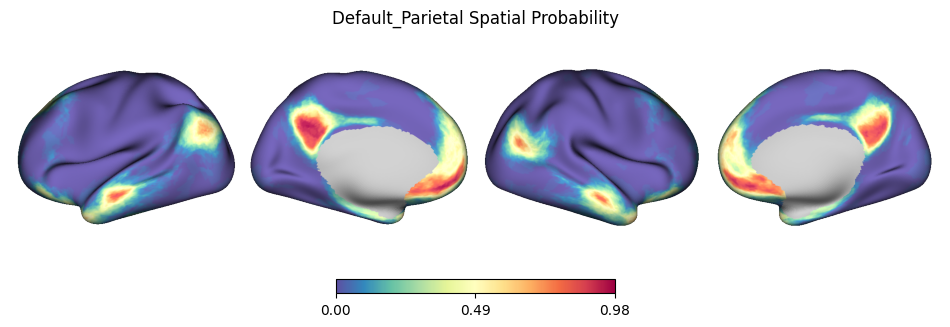

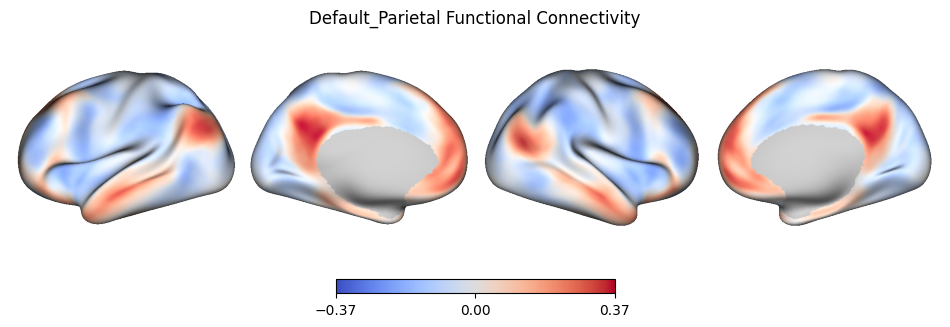

In [999]:
i = 0
spatial_values_i = CAP_tools.utils.cifti_map(None, spatial[i], example_cifti)
FC_values_i = CAP_tools.utils.cifti_map(None, FC[i], example_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(spatial_values_i, cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title(f"{network_labels[i]} Spatial Probability")

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(FC_values_i, cmap=plt.cm.coolwarm, ax=ax)
ax.set_title(f"{network_labels[i]} Functional Connectivity")

In [1000]:
full_data = example_cifti.get_fdata()
vertex_data = get_cortex_data(full_data, example_cifti)

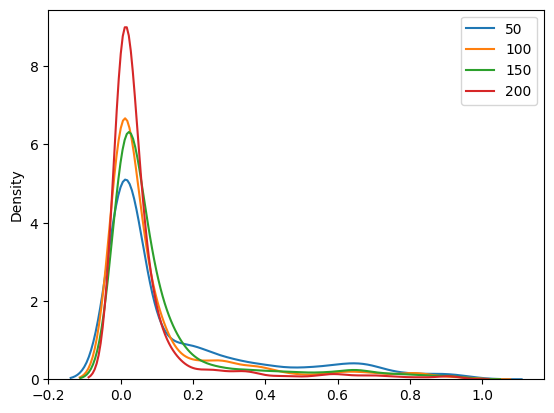

In [1001]:
k_partition = 50

remove_diag = lambda array: array[~np.eye(array.shape[0], dtype=bool)]
for k_step in range(1, 5):
    hf_ind = np.argpartition(spatial[0], -k_partition * k_step)[-k_partition * k_step:][:k_partition]
    hf_roi_vertices = vertex_data[:, hf_ind]
    sns.kdeplot(remove_diag(np.corrcoef(hf_roi_vertices.T)).ravel() ** 2, bw_method=0.2, label=k_step * k_partition)
plt.legend()

In [1025]:
def torch_corr(a, b, **devp):
    """ """
    a = torch.tensor(a.astype("float32"), **devp).T
    b = torch.tensor(b.astype("float32"), **devp).T

    cor = torch.matmul(a, b.T) / (torch.norm(a, dim=1, keepdim=True) * torch.norm(b, dim=1))
    return cor.cpu().numpy()

def np_corr(a, b):
    """ """
    a, b = a.T, b.T
    cor = np.matmul(a, b.T) / (np.linalg.norm(a, axis=1, keepdims=True) * np.linalg.norm(b, axis=1))
    return cor  

In [1017]:
si = spatial[i] >= 0.90
print("Non Zero Mask Count: ", np.count_nonzero(si))

Non Zero Mask Count:  180


In [1018]:
hf_roi_vertices = vertex_data[:, si]
vertex_data[:, ~si].shape

(1859, 59232)

In [1026]:
devp = dict(device="mps")

a = hf_roi_vertices
b = vertex_data[:, :]
# a = np.mean(a, axis=1).reshape(-1, 1)

cor = torch_corr(a, vertex_data, **devp)
cor[cor < 0.0] = 0
# cor[:, si] = 0
# cor = np.mean(cor, axis=0).reshape(1, -1)
w = spatial[i][si] ** 2
w /= np.sum(spatial[i][si])
cor = np.sum(w.reshape(-1, 1) * cor, axis=0, keepdims=True)

Text(0.5, 1.0, 'Default_Parietal Spatial Values')

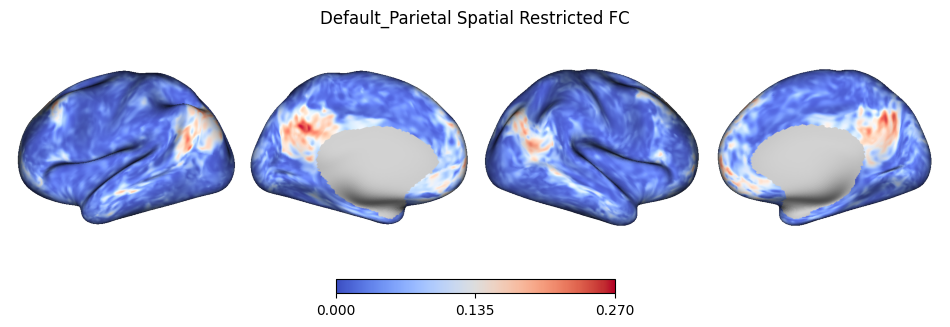

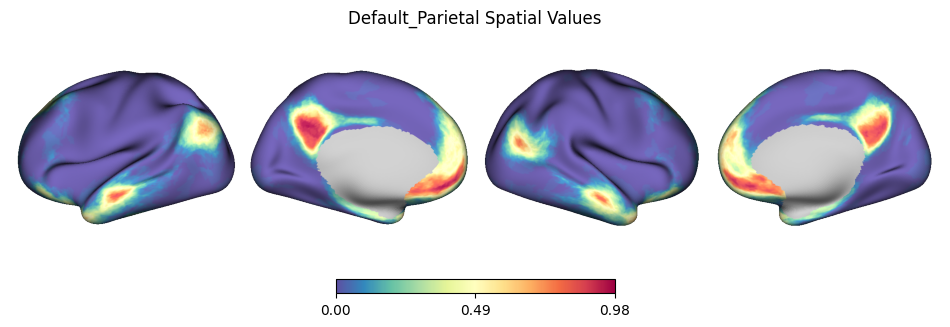

In [1022]:
sfc_values_i = CAP_tools.utils.cifti_map(None, cor[0], example_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(sfc_values_i, cmap=plt.cm.coolwarm, ax=ax)
ax.set_title(f"{network_labels[i]} Spatial Restricted FC")

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(spatial_values_i, cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title(f"{network_labels[i]} Spatial Values")

In [1029]:
rs_dtseries_list_path = "/data/data7/network_control/scripts/_params/EC_CAP_analysis/EC_CAP_analysis_RS_fMRI_maps_dtseries_list.txt"

In [1037]:
with open(rs_dtseries_list_path, "r") as f:
    dtseries_paths = f.read().strip().split()

subject_list = [path.split("/MNI")[0].split("/")[-1] for path in dtseries_paths]

In [1039]:
def get_raw_core_FC(cifti_path, si):
    """ """
    cifti = nb.load(cifti_path)
    full_data = cifti.get_fdata()
    vertex_data = get_cortex_data(full_data, cifti)

    devp = dict(device="mps")
    cor = torch_corr(vertex_data[:, si], vertex_data, **devp)
    return cor

In [1042]:
w = spatial[i][si] ** 2
w /= np.sum(spatial[i][si])
cor = np.sum(w.reshape(-1, 1) * cor, axis=0, keepdims=True)

In [ ]:
cor_set = [get_raw_core_FC(path, si) for path in tqdm(dtseries_paths)]

  0%|          | 0/54 [00:00<?, ?it/s]

pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [ ]:
cor_set = np.array(cor_set)

# Load infomaps Parcellations

In [396]:
sparsity = 0.1
dist_threshold = 10
subcortex = True
prefix = "example"

In [546]:
example_cifti = nb.load(va.constants.EXAMPLE_DTSERIES)

In [398]:
outputs_path = "/data/data7/network_control/projects/voxel_analysis/tests/outputs/"

subcortex_tag = "_SC" if subcortex else ""
param_tag = f"S{sparsity * 10:.0f}_D{dist_threshold}{subcortex_tag}"
partition_path = os.path.join(outputs_path, f"{prefix}_parcellation_{param_tag}.npy")

In [403]:
partition

array([[    0,     1,     2, ..., 91279, 91280, 91281],
       [    1,   249,   349, ...,    86,    86,    86]])

In [523]:
def process_partition(partition, cifti, min_voxels=0, n_vertices=91_282, filter_subcortex=True):
    """ """
    index, groups = partition
    if filter_subcortex:
        subcortex_index = index >= (32_492 * 2)
        index, groups = index[~subcortex_index], np.unique(groups[~subcortex_index], return_inverse=True)[1]

    groups = np.random.permutation(np.max(groups))[groups - 1]    
    unique_groups, counts = np.unique(groups, return_counts=True)
    count_filter = np.isin(groups, unique_groups[counts >= min_voxels])
    
    vertex_labels = np.full(n_vertices, fill_value=np.nan)
    vertex_labels[index[count_filter]] = groups[count_filter]
    
    precision_map_values = CAP_tools.utils.cifti_map(None, vertex_labels, cifti)
    return precision_map_values, (index, groups)

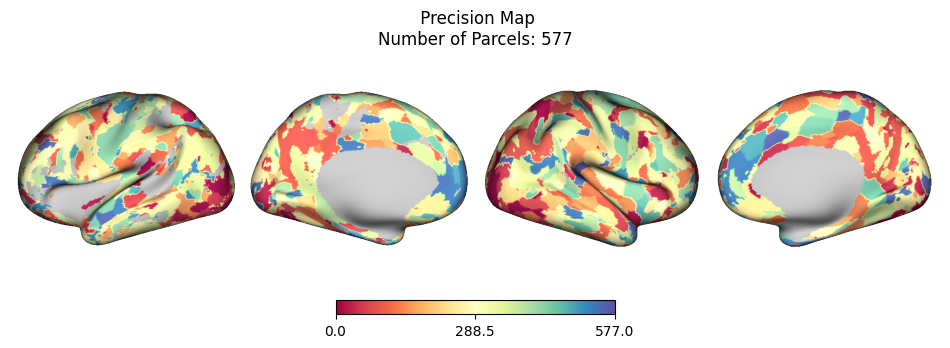

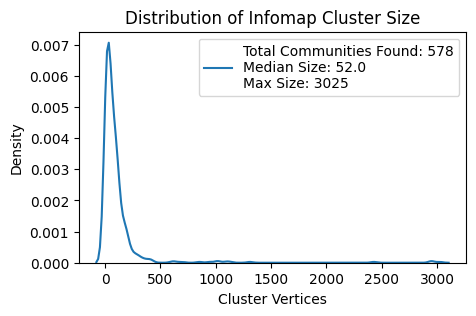

In [524]:
partition = np.load(partition_path)
precision_map_values, partition = process_partition(partition, rs_dtseries)

va.pm.plot_precision_map(precision_map_values)
va.pm.precision_map_QC_plots(partition)
va.pm.write_dlabel_precision_map(precision_map_values, dlabel_path, label="example_precision_map")

# Distance and Subcortical Masking

In [69]:
sfm.get_cortex_mask(rs_dtseries)

array([ True,  True,  True, ..., False, False, False])

In [70]:
dist_dir = "/data/data7/network_control/projects/network_control/resources/brain_distances"
ex_dist_txt_path = os.path.join(dist_dir, "Schaefer400_geodesic_distmat_R.txt")
ex_dist_txt_path = os.path.join(dist_dir, "dense_geodesic_distmat_R.txt")

geodesic_distmat_L_path = os.path.join(dist_dir, "dense_geodesic_distmat_L.txt")
geodesic_distmat_R_path = os.path.join(dist_dir, "dense_geodesic_distmat_R.txt")

In [90]:
from scipy.sparse import lil_matrix

def create_sparse_matrix_from_txt(file_path, threshold=10.0, num_voxels=32_492):
    sparse_matrix = lil_matrix((num_voxels, num_voxels), dtype=np.float32)

    pbar = tqdm(total=num_voxels)
    with open(file_path, 'r') as f:
        for i, line in enumerate(f):
            distances = line.strip().split()
            for j, dist in enumerate(distances):
                dist_value = float(dist)
                if dist_value <= threshold and i != j:
                    sparse_matrix[i, j] = dist_value
            pbar.update(1)
    return sparse_matrix

In [91]:
threshold = 30
geodesic_dist_mask_R = create_sparse_matrix_from_txt(geodesic_distmat_R_path, threshold=threshold)
geodesic_dist_mask_L = create_sparse_matrix_from_txt(geodesic_distmat_L_path, threshold=threshold)

  0%|          | 0/32492 [00:00<?, ?it/s]

  0%|          | 0/32492 [00:00<?, ?it/s]

In [92]:
geodesic_mask = scipy.sparse.block_diag([geodesic_dist_mask_L, geodesic_dist_mask_R])
geodesic_mask.resize(91282, 91282)
geodesic_mask = geodesic_mask.tocsr()

geodesic_mask_path = os.path.join(dist_dir, f"geodesic_mask_{threshold}.npz")
scipy.sparse.save_npz(geodesic_mask_path, geodesic_mask)
geodesic_mask

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 111710086 stored elements and shape (91282, 91282)>

# Calculate Euclidian Mask

In [643]:
subcortex_index = ~sfm.get_cortex_mask(rs_dtseries)
subcortex_mask_path = os.path.join(dist_dir, "subcortex_mask.npy")
np.save(subcortex_mask_path, subcortex_index)

In [644]:
subcortex_index = np.load(subcortex_mask_path)
geodesic_mask = scipy.sparse.load_npz(geodesic_mask_path)

In [639]:
sc = tmt.matrix.SparseCorrelator.run(rs_voxels[:, :], sparsity_percent=0.1, mask=geodesic_mask,
                                     exclude_index=subcortex_index,
                                     block_size=4000)

SparseCorrelator Block Analysis:   0%|          | 0/8464.0 [00:00<?, ?it/s]

In [645]:
sc = tmt.matrix.Runner.run(rs_voxels[:, :], mask=geodesic_mask,
                                     exclude_index=subcortex_index,
                                     block_size=4000)

<Axes: ylabel='Density'>

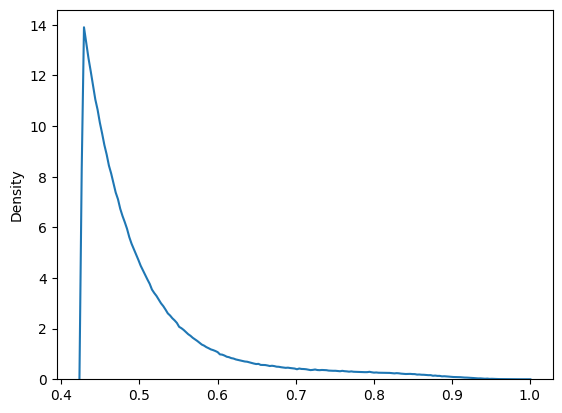

In [37]:
sns.kdeplot(sc.data, bw_method=0.01)

In [38]:
from sklearn.cluster import SpectralClustering
from scipy.sparse import csr_matrix

# Assuming 'sparse_matrix' is your scipy sparse matrix
# model = SpectralClustering(n_clusters=3, affinity='precomputed', n_init=100)
# labels = model.fit_predict(sc)

In [51]:
G = nx.from_scipy_sparse_matrix(sc)

AttributeError: module 'networkx' has no attribute 'from_scipy_sparse_matrix'

In [50]:
import networkx as nx
import community as community_louvain

partition = community_louvain.best_partition(G)

AttributeError: module 'networkx' has no attribute 'from_scipy_sparse_matrix'

In [41]:
(sc.sum(axis=1) == 0).sum()

np.int64(105)

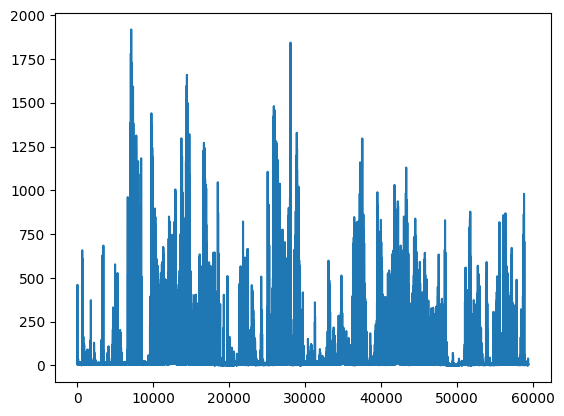

In [49]:
plt.plot(sc.getnnz(axis=0))

# Infomap

# EV Maxs

In [129]:
ev_maxs = tmt.matrix.block_analysis(voxel_data[:, :10000], tmt.matrix.ev_aggregator,
                                    device="mps", use_torch=True)

  0%|          | 0/10 [00:00<?, ?it/s]

In [56]:
(ev_maxs >= 0.5).mean() * 100

np.float64(86.18)

<Axes: ylabel='Density'>

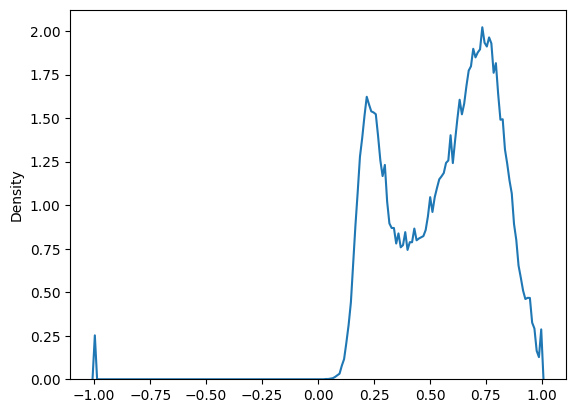

In [179]:
sns.kdeplot(ev_maxs, bw_method=0.01)

[] within parcel vs out of parcel correlations for voxel level

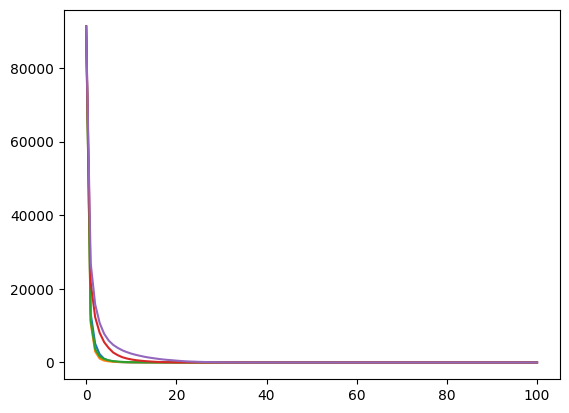

In [558]:
plt.plot(na_counts.T);

In [543]:
na_counts = {thres: [] for thres in np.linspace(0, 1, 101)}